# SMM4H-HeaRD 2026 Task 7 — Exploratory Data Analysis

In [1]:
import ast
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["pdf.fonttype"] = 42

BLUE_PRIMARY = "#1f77b4"
BLUE_DARK    = "#0d4a77"
BLUE_LIGHT   = "#7db8e8"
MULTI_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

DATA_DIR  = Path("datasets")
PLOTS_DIR = Path("out/plots")
CACHE_DIR = Path("out/cache")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, stem):
    path = PLOTS_DIR / f"{stem}.pdf"
    fig.savefig(path)
    print(f"  saved -> {path}")

print("Plots directory:", PLOTS_DIR.resolve())

Plots directory: /home/vl4dio4n/workspace/facultate/master/anul1/ln/proiect_v2/out/plots


## 1. Load and parse the three splits

In [2]:
def load_split(path, has_labels=True):
    df = pd.read_csv(path)
    df["tokens"] = df["tokens"].apply(ast.literal_eval)
    if has_labels:
        df["ner_tags"] = df["ner_tags"].apply(ast.literal_eval)
        df["labels"] = df["labels"].apply(ast.literal_eval)
    return df

df_train = load_split(DATA_DIR / "new_train_data.csv")
df_dev   = load_split(DATA_DIR / "new_dev_data.csv")
df_test  = load_split(DATA_DIR / "new_test_data.csv", has_labels=False)

summary = pd.DataFrame({
    "split": ["train", "dev", "test"],
    "rows (segments)": [len(df_train), len(df_dev), len(df_test)],
    "unique IDs (posts)": [df_train["ID"].nunique(), df_dev["ID"].nunique(), df_test["ID"].nunique()],
    "avg tokens/row": [
        df_train["tokens"].map(len).mean().round(1),
        df_dev["tokens"].map(len).mean().round(1),
        df_test["tokens"].map(len).mean().round(1),
    ],
})
summary

,split,rows (segments),unique IDs (posts),avg tokens/row
0,train,842,743,20.5
1,dev,258,258,20.2
2,test,578,578,533.7


## 2. Class distribution (token-level)

In [3]:
LABEL_ORDER = [
    "O",
    "B-ClinicalImpacts", "I-ClinicalImpacts",
    "B-SocialImpacts",   "I-SocialImpacts",
]

def tag_counts(df):
    counter = Counter()
    for tags in df["ner_tags"]:
        counter.update(tags)
    return counter

train_counts = tag_counts(df_train)
dev_counts   = tag_counts(df_dev)

df_counts = pd.DataFrame({
    "label": LABEL_ORDER,
    "train": [train_counts[l] for l in LABEL_ORDER],
    "dev":   [dev_counts[l]   for l in LABEL_ORDER],
})
df_counts["train %"] = 100 * df_counts["train"] / df_counts["train"].sum()
df_counts["dev %"]   = 100 * df_counts["dev"]   / df_counts["dev"].sum()
df_counts

,label,train,dev,train %,dev %
0,O,16198,4830,94.054117,92.528736
1,B-ClinicalImpacts,256,92,1.486471,1.762452
2,I-ClinicalImpacts,360,131,2.090350,2.509579
3,B-SocialImpacts,87,27,0.505168,0.517241
4,I-SocialImpacts,321,140,1.863895,2.681992


  saved -> out/plots/01_class_distribution.pdf


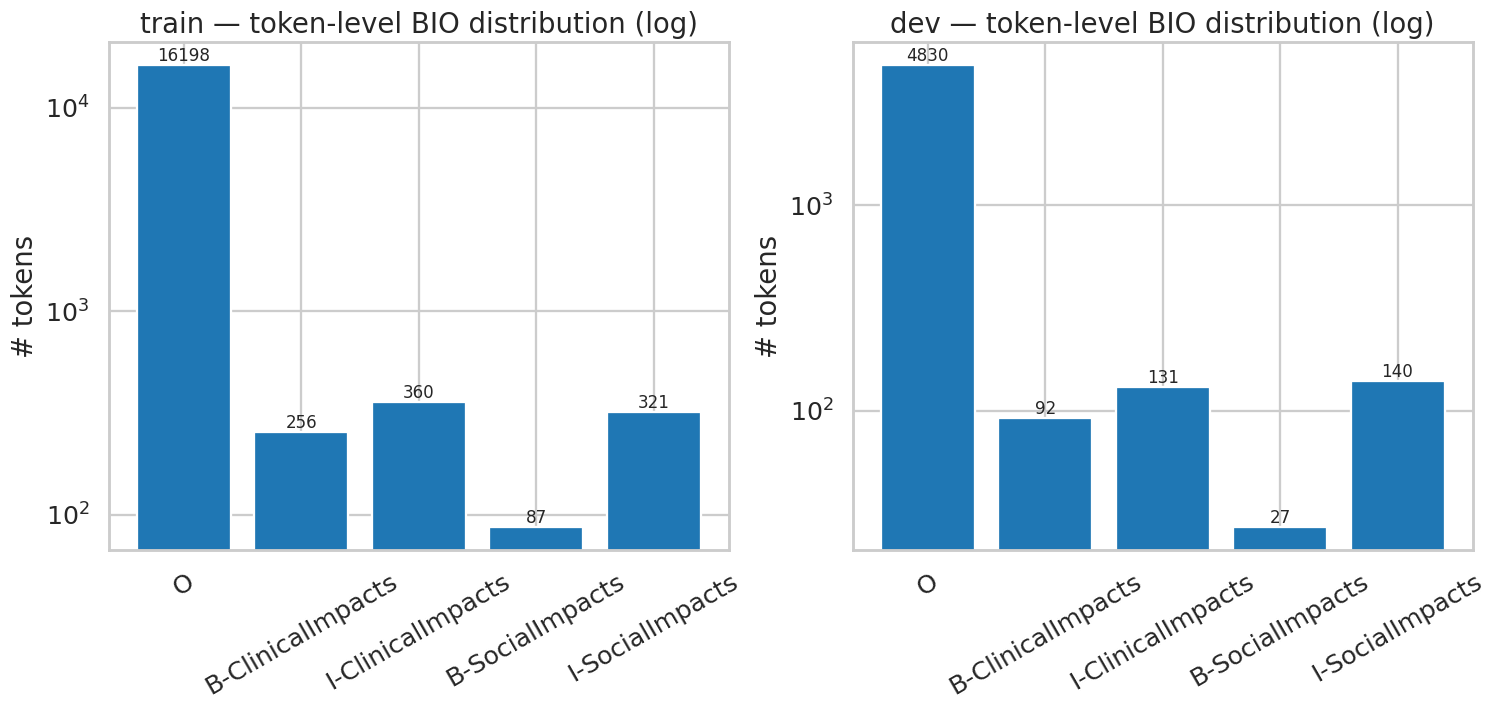

Train: O=16198, impacts=1024 (5.95%)
Imbalance ratio O:impact = 15.8:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, split, counts in zip(axes, ["train", "dev"], [train_counts, dev_counts]):
    vals = [counts[l] for l in LABEL_ORDER]
    ax.bar(LABEL_ORDER, vals, color=BLUE_PRIMARY)
    ax.set_yscale("log")
    ax.set_title(f"{split} — token-level BIO distribution (log)")
    ax.set_ylabel("# tokens")
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(vals):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=11)
save_fig(fig, "01_class_distribution")
plt.show()

total_train = sum(train_counts.values())
o_train = train_counts["O"]
impact_train = total_train - o_train
print(f"Train: O={o_train}, impacts={impact_train} ({100*impact_train/total_train:.2f}%)")
print(f"Imbalance ratio O:impact = {o_train/impact_train:.1f}:1")

## 3. Sequence length distribution

In [5]:
lens_train = df_train["tokens"].map(len).values
lens_dev   = df_dev["tokens"].map(len).values
lens_test  = df_test["tokens"].map(len).values

stats_rows = []
for name, arr in [("train", lens_train), ("dev", lens_dev), ("test", lens_test)]:
    stats_rows.append({
        "split": name,
        "mean": arr.mean().round(1),
        "median": int(np.median(arr)),
        "p90": int(np.percentile(arr, 90)),
        "p95": int(np.percentile(arr, 95)),
        "p99": int(np.percentile(arr, 99)),
        "max": int(arr.max()),
        ">128": f"{100*(arr>128).mean():.1f}%",
        ">256": f"{100*(arr>256).mean():.1f}%",
    })
pd.DataFrame(stats_rows)

,split,mean,median,p90,p95,p99,max,>128,>256
0,train,20.5,17,37,46,70,123,0.0%,0.0%
1,dev,20.2,17,37,41,59,119,0.0%,0.0%
2,test,533.7,116,1200,2232,6322,9009,49.1%,41.2%


  saved -> out/plots/02_sequence_length.pdf


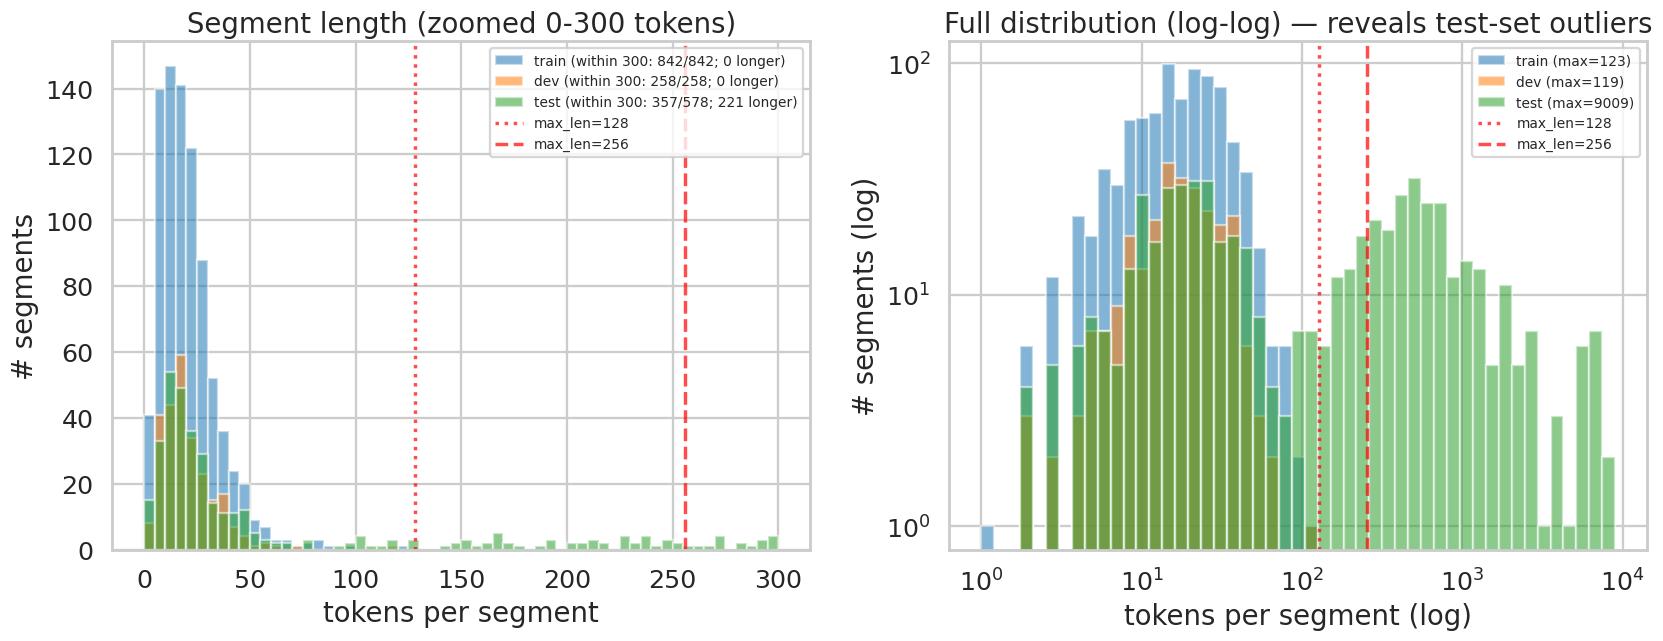

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

XLIM_FOCUS = 300
bins_focus = np.arange(0, XLIM_FOCUS + 5, 5)
hist_colors = MULTI_PALETTE[:3]
for (arr, name), color in zip([(lens_train, "train"), (lens_dev, "dev"), (lens_test, "test")], hist_colors):
    within = arr[arr <= XLIM_FOCUS]
    outside = (arr > XLIM_FOCUS).sum()
    axes[0].hist(within, bins=bins_focus, alpha=0.55, color=color,
                 label=f"{name} (within {XLIM_FOCUS}: {len(within)}/{len(arr)}; {outside} longer)")
for thr, style in [(128, ":"), (256, "--")]:
    axes[0].axvline(thr, color="red", linestyle=style, alpha=0.7, label=f"max_len={thr}")
axes[0].set_xlabel("tokens per segment")
axes[0].set_ylabel("# segments")
axes[0].set_title(f"Segment length (zoomed 0-{XLIM_FOCUS} tokens)")
axes[0].legend(fontsize=9)

x_max_full = int(max(lens_train.max(), lens_dev.max(), lens_test.max()))
bins_full = np.logspace(0, np.log10(x_max_full + 1), 50)
for (arr, name), color in zip([(lens_train, "train"), (lens_dev, "dev"), (lens_test, "test")], hist_colors):
    axes[1].hist(arr, bins=bins_full, alpha=0.55, color=color, label=f"{name} (max={arr.max()})")
for thr, style in [(128, ":"), (256, "--")]:
    axes[1].axvline(thr, color="red", linestyle=style, alpha=0.7, label=f"max_len={thr}")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("tokens per segment (log)")
axes[1].set_ylabel("# segments (log)")
axes[1].set_title("Full distribution (log-log) — reveals test-set outliers")
axes[1].legend(fontsize=9)

save_fig(fig, "02_sequence_length")
plt.show()

## 4. Entity span length distribution

In [7]:
def extract_spans(tags):
    spans = []
    cur_type = None
    cur_len = 0
    for t in tags:
        if t.startswith("B-"):
            if cur_type is not None:
                spans.append((cur_type, cur_len))
            cur_type = t[2:]
            cur_len = 1
        elif t.startswith("I-") and cur_type == t[2:]:
            cur_len += 1
        else:
            if cur_type is not None:
                spans.append((cur_type, cur_len))
                cur_type = None
                cur_len = 0
    if cur_type is not None:
        spans.append((cur_type, cur_len))
    return spans

def all_spans(df):
    result = []
    for tags in df["ner_tags"]:
        result.extend(extract_spans(tags))
    return result

spans_train = all_spans(df_train)
spans_dev   = all_spans(df_dev)

span_df = pd.DataFrame(spans_train + spans_dev, columns=["type", "length"])
span_df["split"] = ["train"] * len(spans_train) + ["dev"] * len(spans_dev)

span_stats = span_df.groupby(["split", "type"])["length"].describe()[["count", "mean", "50%", "max"]].round(2)
span_stats

count  mean  50%   max
split type                                   
dev   ClinicalImpacts   92.0  2.42  1.5  15.0
      SocialImpacts     27.0  6.19  5.0  19.0
train ClinicalImpacts  256.0  2.41  1.0  24.0
      SocialImpacts     87.0  4.69  4.0  24.0

  saved -> out/plots/03_span_length.pdf


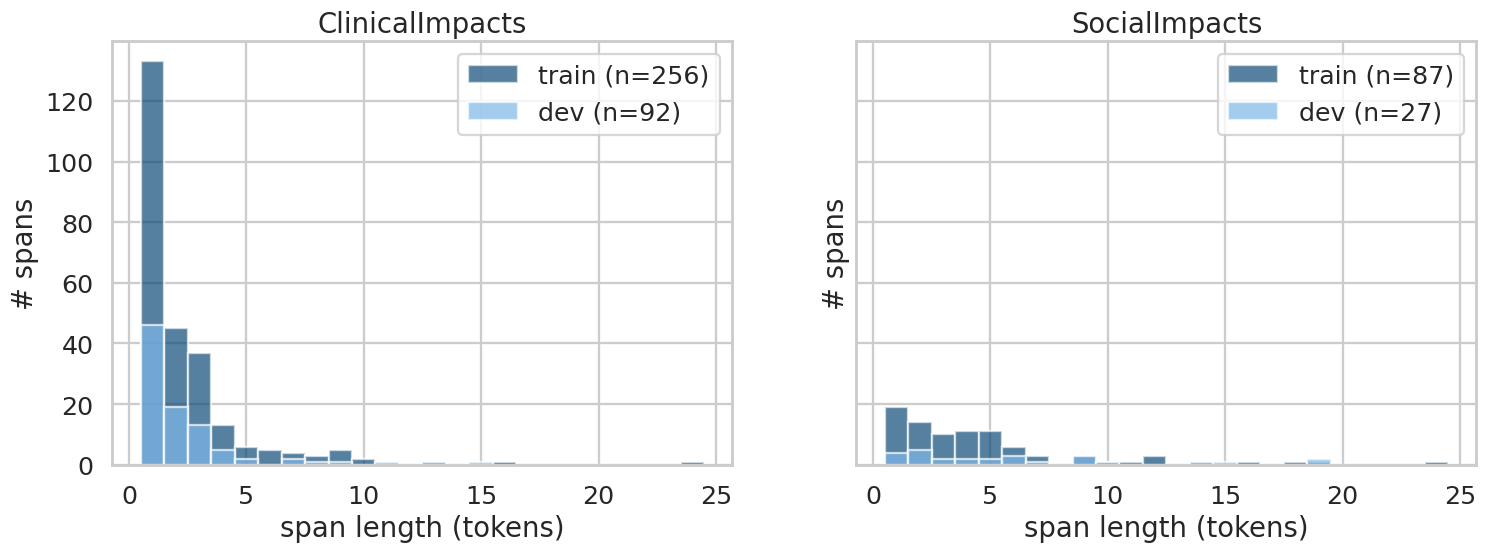

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, t in zip(axes, ["ClinicalImpacts", "SocialImpacts"]):
    sub = span_df[span_df["type"] == t]
    for split, color in zip(["train", "dev"], [BLUE_DARK, BLUE_LIGHT]):
        lens = sub[sub["split"] == split]["length"]
        ax.hist(lens, bins=np.arange(1, lens.max() + 2) - 0.5,
                alpha=0.7, color=color, label=f"{split} (n={len(lens)})")
    ax.set_title(t)
    ax.set_xlabel("span length (tokens)")
    ax.set_ylabel("# spans")
    ax.legend()
save_fig(fig, "03_span_length")
plt.show()

## 5. Segments with vs without entities

  saved -> out/plots/04_entity_category.pdf


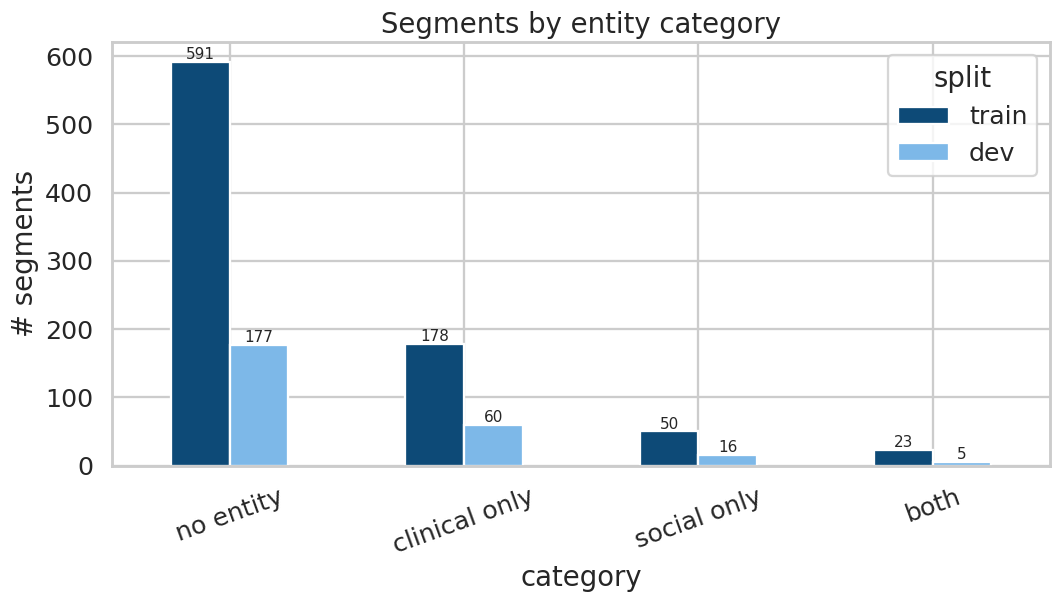

split,dev,train
category,,
no entity,177,591
clinical only,60,178
social only,16,50
both,5,23


In [9]:
def entity_category(tags):
    has_clin = any(t.endswith("ClinicalImpacts") for t in tags)
    has_soc  = any(t.endswith("SocialImpacts")   for t in tags)
    if has_clin and has_soc: return "both"
    if has_clin: return "clinical only"
    if has_soc:  return "social only"
    return "no entity"

rows = []
for name, df in [("train", df_train), ("dev", df_dev)]:
    cats = df["ner_tags"].map(entity_category).value_counts()
    for c in ["no entity", "clinical only", "social only", "both"]:
        rows.append({"split": name, "category": c, "count": int(cats.get(c, 0))})
ent_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
pivot = ent_df.pivot(index="category", columns="split", values="count").loc[["no entity", "clinical only", "social only", "both"]]
pivot[["train", "dev"]].plot(kind="bar", ax=ax, color=[BLUE_DARK, BLUE_LIGHT])
ax.set_title("Segments by entity category")
ax.set_ylabel("# segments")
ax.tick_params(axis="x", rotation=20)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
save_fig(fig, "04_entity_category")
plt.show()
pivot

## 6. Subreddit breakdown

In [10]:
def extract_subreddit(tokens):
    subs = []
    for i, tok in enumerate(tokens):
        if tok == "submission_subreddit" and i + 3 < len(tokens):
            if tokens[i + 1] == ":" and tokens[i + 2] == "-":
                candidate = tokens[i + 3]
                if candidate and re.match(r"^[A-Za-z0-9_]+$", candidate):
                    subs.append(candidate)
    return subs[-1] if subs else None

df_train["subreddit"] = df_train["tokens"].map(extract_subreddit)
df_dev["subreddit"]   = df_dev["tokens"].map(extract_subreddit)
df_test["subreddit"]  = df_test["tokens"].map(extract_subreddit)

cov = pd.DataFrame({
    "split": ["train", "dev", "test"],
    "segments": [len(df_train), len(df_dev), len(df_test)],
    "with_subreddit": [df_train["subreddit"].notna().sum(), df_dev["subreddit"].notna().sum(), df_test["subreddit"].notna().sum()],
})
cov["coverage %"] = (100 * cov["with_subreddit"] / cov["segments"]).round(1)
cov

,split,segments,with_subreddit,coverage %
0,train,842,131,15.6
1,dev,258,39,15.1
2,test,578,339,58.7


  saved -> out/plots/05_subreddits.pdf


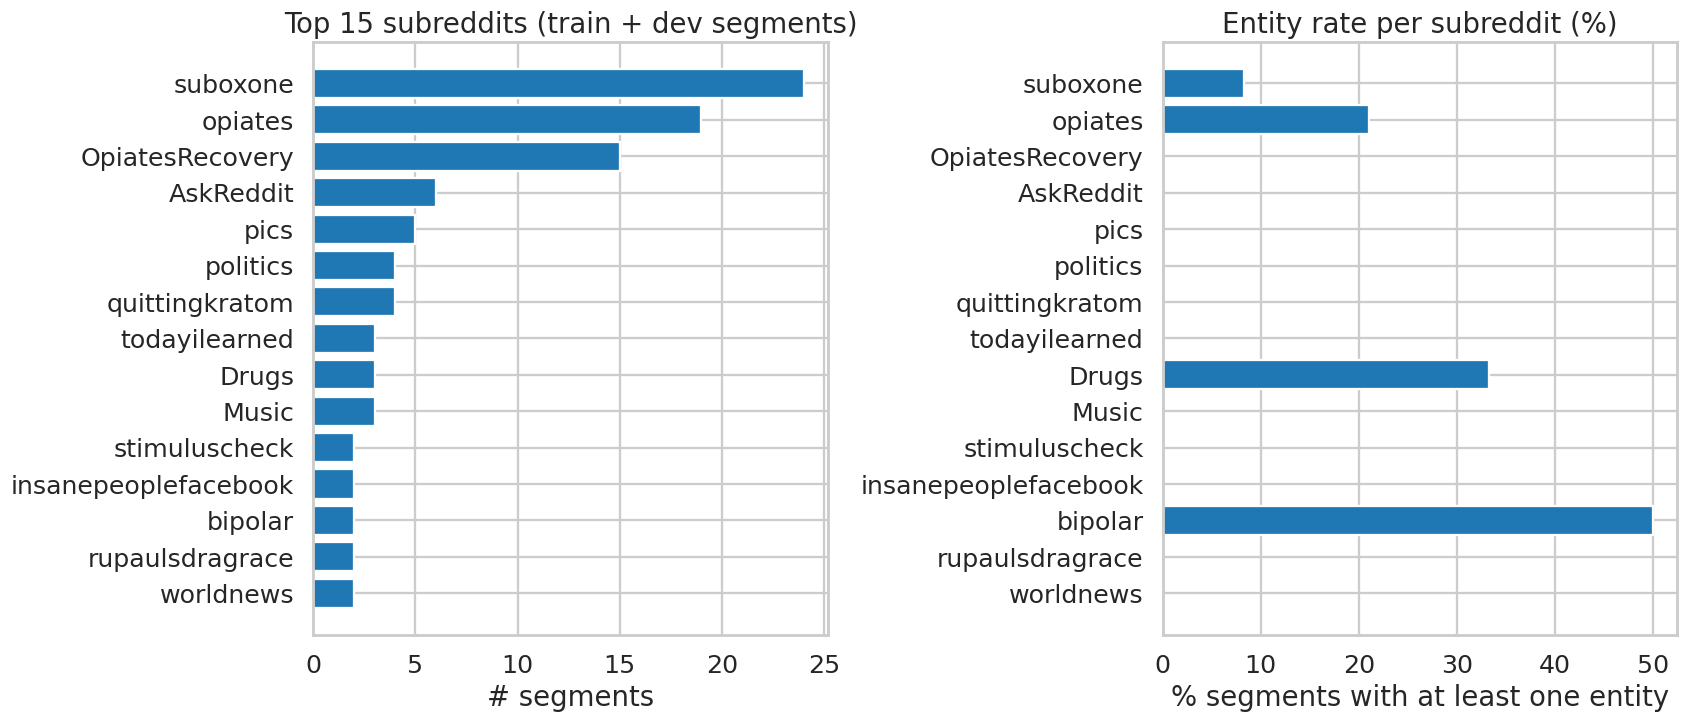

In [11]:
combined = pd.concat([df_train, df_dev], ignore_index=True)
combined["has_entity"] = combined["ner_tags"].map(lambda tags: any(t != "O" for t in tags))

top_subs = combined["subreddit"].value_counts().head(15)
ent_by_sub = (combined[combined["subreddit"].isin(top_subs.index)]
              .groupby("subreddit")["has_entity"].mean() * 100)
ent_by_sub = ent_by_sub.reindex(top_subs.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.65)

axes[0].barh(top_subs.index[::-1], top_subs.values[::-1], color=BLUE_PRIMARY)
axes[0].set_title("Top 15 subreddits (train + dev segments)")
axes[0].set_xlabel("# segments")

axes[1].barh(ent_by_sub.index[::-1], ent_by_sub.values[::-1], color=BLUE_PRIMARY)
axes[1].set_title("Entity rate per subreddit (%)")
axes[1].set_xlabel("% segments with at least one entity")

save_fig(fig, "05_subreddits")
plt.show()

## 7. Entity co-occurrence

  saved -> out/plots/06_co_occurrence.pdf


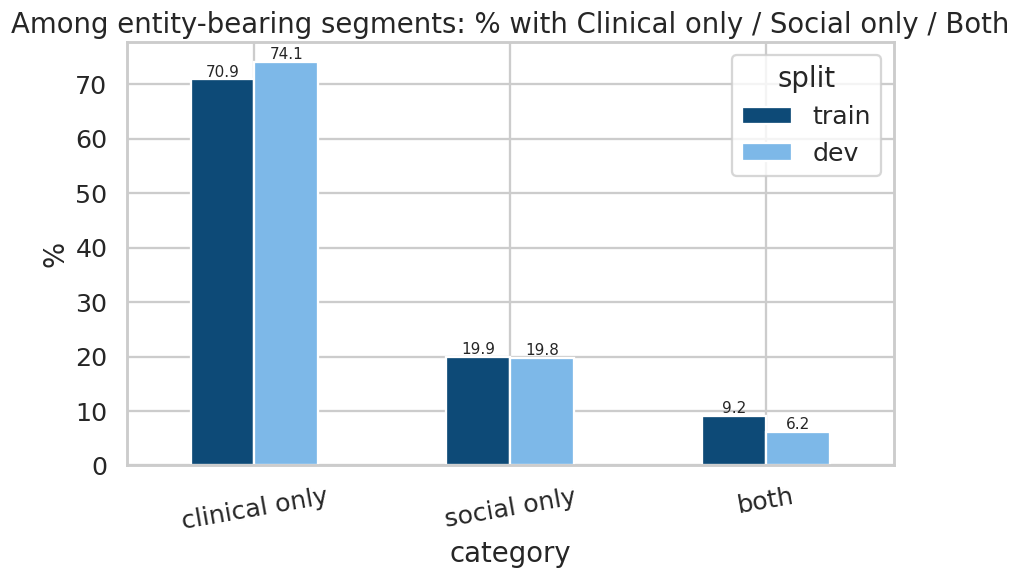

split,dev,train
category,,
both,6.2,9.2
clinical only,74.1,70.9
social only,19.8,19.9


In [12]:
co = ent_df.pivot(index="category", columns="split", values="count")
with_any = co.drop("no entity").sum()

fig, ax = plt.subplots(figsize=(9, 5))
co_pct = 100 * co.drop("no entity") / with_any
co_pct.loc[["clinical only", "social only", "both"]][["train", "dev"]].plot(
    kind="bar", ax=ax, color=[BLUE_DARK, BLUE_LIGHT])
ax.set_title("Among entity-bearing segments: % with Clinical only / Social only / Both")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=10)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=10)
save_fig(fig, "06_co_occurrence")
plt.show()
co_pct.round(1)

## 8. Word clouds of Clinical and Social impact spans

  saved -> out/plots/07_wordclouds.pdf


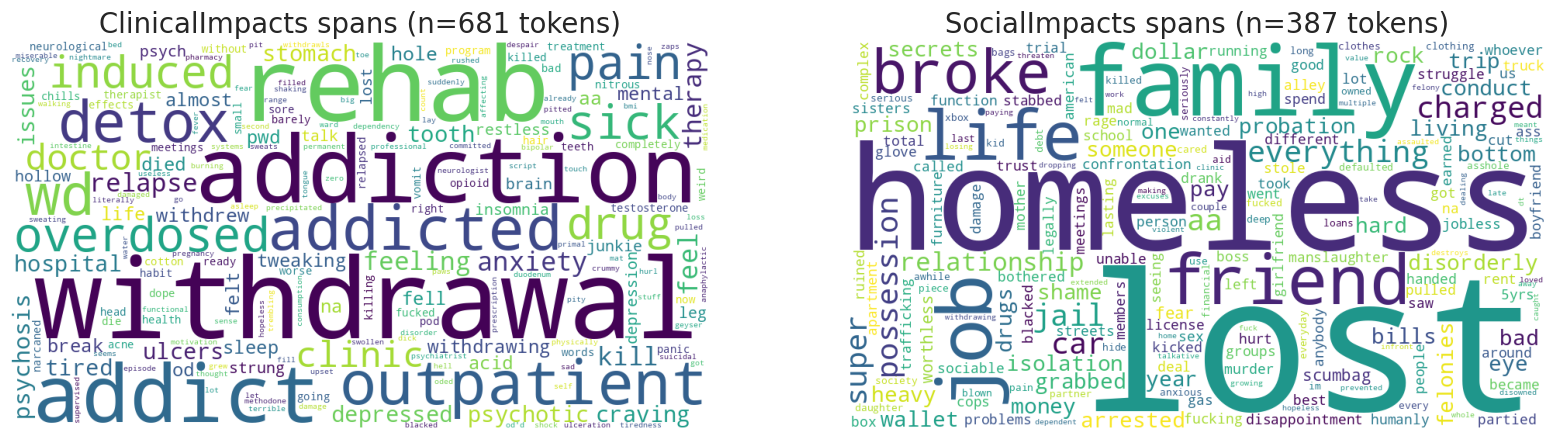

Top 20 Clinical tokens: [('withdrawal', 23), ('rehab', 20), ('addiction', 20), ('addict', 14), ('outpatient', 8), ('out', 8), ('addicted', 8), ('detox', 7), ('withdrawals', 7), ('overdosed', 7), ('pain', 7), ('sick', 7), ('wd', 6), ('rehabs', 6), ('clinic', 6), ('up', 6), ('anxiety', 5), ('doctor', 5), ('therapy', 5), ('relapse', 5)]
Top 20 Social   tokens: [('lost', 10), ('homeless', 8), ('family', 7), ('no', 4), ('job', 4), ('out', 4), ('life', 4), ('broke', 3), ('up', 3), ('everything', 3), ('aa', 3), ('super', 3), ('jail', 3), ('charged', 3), ("couldn't", 3), ('car', 3), ('friends', 3), ('from', 3), ('other', 3), ('as', 3)]


In [13]:
def collect_span_words(df, target_type):
    words = []
    for tokens, tags in zip(df["tokens"], df["ner_tags"]):
        cur_words = []
        in_span = False
        for tok, tag in zip(tokens, tags):
            if tag == f"B-{target_type}":
                if cur_words:
                    words.extend(cur_words)
                cur_words = [tok.lower()]
                in_span = True
            elif tag == f"I-{target_type}" and in_span:
                cur_words.append(tok.lower())
            else:
                if cur_words:
                    words.extend(cur_words)
                cur_words = []
                in_span = False
        if cur_words:
            words.extend(cur_words)
    return words

clinical_words = collect_span_words(df_train, "ClinicalImpacts") + collect_span_words(df_dev, "ClinicalImpacts")
social_words   = collect_span_words(df_train, "SocialImpacts")   + collect_span_words(df_dev, "SocialImpacts")

STOP = {"the", "a", "an", "of", "and", "or", "to", "in", "on", "at", "my", "i", "me", "was",
        "is", "be", "for", "with", "it", "its", "ve", "d", "t", "'", "s", "are", "all", "by", "m"}
clinical_clean = [w for w in clinical_words if w not in STOP and len(w) > 1]
social_clean   = [w for w in social_words   if w not in STOP and len(w) > 1]

def make_wc(words):
    text = " ".join(words)
    return WordCloud(width=900, height=500, background_color="white", collocations=False).generate(text)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(make_wc(clinical_clean))
axes[0].set_title(f"ClinicalImpacts spans (n={len(clinical_clean)} tokens)")
axes[0].axis("off")
axes[1].imshow(make_wc(social_clean))
axes[1].set_title(f"SocialImpacts spans (n={len(social_clean)} tokens)")
axes[1].axis("off")
save_fig(fig, "07_wordclouds")
plt.show()

print("Top 20 Clinical tokens:", Counter(clinical_clean).most_common(20))
print("Top 20 Social   tokens:", Counter(social_clean).most_common(20))

## 9. Segment-level perspective — LLM-based classification

In [14]:
import os

from dotenv import load_dotenv
load_dotenv()
hf_token = os.getenv("HF_ADMIN_READ_TOKEN")

def strip_metadata(tokens):
    out = []
    i, n = 0, len(tokens)
    while i < n:
        if tokens[i] == "submission_title" and i + 2 < n and tokens[i+1] == ":" and tokens[i+2] == "-":
            i += 3
        elif tokens[i] == "submission_subreddit" and i + 3 < n and tokens[i+1] == ":" and tokens[i+2] == "-":
            i += 4
        else:
            out.append(tokens[i])
            i += 1
    return " ".join(out)

def build_corpus(dataframes_and_names):
    records = []
    for df, split in dataframes_and_names:
        for idx, row in df.iterrows():
            records.append({
                "split": split,
                "row_id": int(idx),
                "ID": row["ID"],
                "text": strip_metadata(row["tokens"]).strip(),
            })
    return records

corpus = build_corpus([(df_train, "train"), (df_dev, "dev"), (df_test, "test")])
print(f"Total segments to classify: {len(corpus)}")
print("Example text:", corpus[0]["text"][:200])

Total segments to classify: 1678
Example text: " " I've been doing it wrong all this time Someone is going to have a lot of regrets when they get this super fun an and nasty yeast and / or bladder infection " " My boyfriend and I just broke up . I


In [15]:
LLM_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
CACHE_PATH = CACHE_DIR / "perspective_llm.json"
MAX_CHARS = 2000

SYSTEM_PROMPT = (
    "You label the narrative perspective of a Reddit comment about drugs, addiction, or recovery. "
    "Answer with exactly ONE word: FIRST, THIRD, or OTHER."
)

USER_TEMPLATE = (
    "FIRST = the author talks about themselves and their own experience (uses 'I', 'me', 'my').\n"
    "THIRD = the author talks about another specific person (friend, family, 'he/she/they').\n"
    "OTHER = general advice, factual statement, question or opinion with no personal experience.\n\n"
    "Comment: \"{text}\"\n\n"
    "Answer:"
)

def normalise_prediction(raw):
    s = raw.strip().upper()
    for tag in ["FIRST", "THIRD", "OTHER"]:
        if tag in s:
            return tag
    return "OTHER"

def load_cache():
    if CACHE_PATH.exists():
        return json.loads(CACHE_PATH.read_text())
    return {}

def save_cache(cache):
    CACHE_PATH.write_text(json.dumps(cache, indent=0))

def cache_key(rec):
    return f"{rec['split']}:{rec['row_id']}"

cache = load_cache()
pending = [r for r in corpus if cache_key(r) not in cache]
print(f"Cached: {len(corpus) - len(pending)} / {len(corpus)}; pending: {len(pending)}")

Cached: 1678 / 1678; pending: 0


In [16]:
if pending:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from tqdm.auto import tqdm

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading LLM: {LLM_MODEL_NAME} (4-bit on {device}) ...")

    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME, token=hf_token)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4",
    )
    model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_NAME, quantization_config=bnb_config, device_map="cuda", token=hf_token
    )
    model.eval()
    print(f"  GPU memory after load: {torch.cuda.memory_allocated()/1e9:.1f} GB")

    def classify_batch(records):
        messages_list = [
            [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": USER_TEMPLATE.format(text=r["text"][:MAX_CHARS])},
            ]
            for r in records
        ]
        prompts = [
            tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
            for m in messages_list
        ]
        enc = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=1536).to(device)
        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=4,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=tokenizer.pad_token_id,
            )
        new_tokens = out[:, enc["input_ids"].shape[1]:]
        decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
        return [normalise_prediction(d) for d in decoded]

    BATCH = 8
    for i in tqdm(range(0, len(pending), BATCH), desc="LLM classify"):
        batch = pending[i:i+BATCH]
        preds = classify_batch(batch)
        for rec, p in zip(batch, preds):
            cache[cache_key(rec)] = p
        if (i // BATCH) % 10 == 0:
            save_cache(cache)
    save_cache(cache)

    del model
    torch.cuda.empty_cache()
    print("LLM classification complete and cached.")
else:
    print("All segments already cached — skipping LLM inference.")

All segments already cached — skipping LLM inference.


In [17]:
perspective_label = {"FIRST": "first-person", "THIRD": "third-person", "OTHER": "other"}

for df, split in [(df_train, "train"), (df_dev, "dev"), (df_test, "test")]:
    df["perspective"] = df.index.map(lambda idx: perspective_label.get(cache[f"{split}:{idx}"], "other"))

persp_order = ["first-person", "third-person", "other"]
persp_counts = pd.DataFrame({
    split: df["perspective"].value_counts().reindex(persp_order, fill_value=0).values
    for split, df in [("train", df_train), ("dev", df_dev), ("test", df_test)]
}, index=persp_order)
persp_counts_pct = (100 * persp_counts / persp_counts.sum()).round(1)

print("Counts:")
print(persp_counts)
print("\nPercentages:")
print(persp_counts_pct)

Counts:
              train  dev  test
first-person    380  119   411
third-person     89   26    44
other           373  113   123

Percentages:
              train   dev  test
first-person   45.1  46.1  71.1
third-person   10.6  10.1   7.6
other          44.3  43.8  21.3


  saved -> out/plots/08_perspective_distribution.pdf


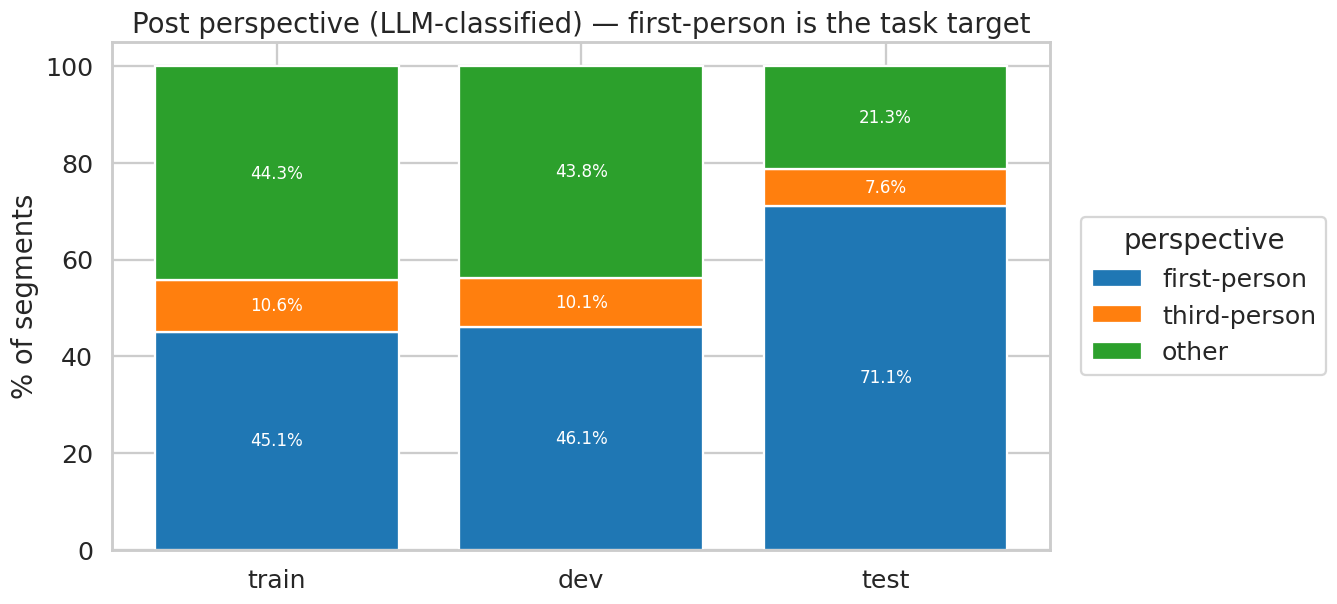

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(3)
for i, p in enumerate(persp_order):
    vals = persp_counts_pct.loc[p].values
    ax.bar(persp_counts.columns, vals, bottom=bottom, label=p, color=MULTI_PALETTE[i])
    for j, v in enumerate(vals):
        if v > 2:
            ax.text(j, bottom[j] + v / 2, f"{v:.1f}%", ha="center", va="center", fontsize=11, color="white")
    bottom += vals
ax.set_ylabel("% of segments")
ax.set_title("Post perspective (LLM-classified) — first-person is the task target")
ax.legend(title="perspective", loc="center left", bbox_to_anchor=(1.02, 0.5))
save_fig(fig, "08_perspective_distribution")
plt.show()

  saved -> out/plots/09_entity_rate_by_perspective.pdf


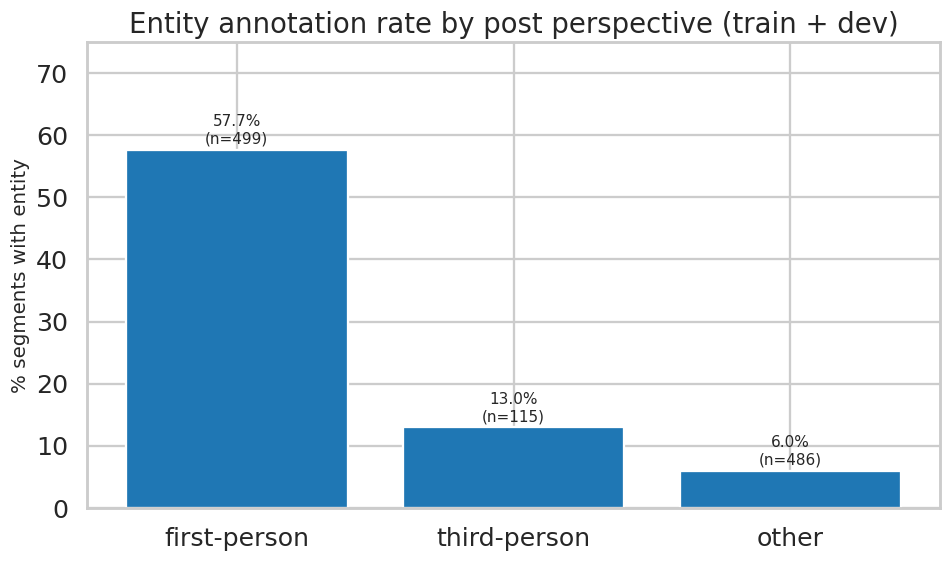

,count,entity_rate %
perspective,,
first-person,499,57.7
third-person,115,13.0
other,486,6.0


In [19]:
comb = pd.concat([df_train.assign(split="train"), df_dev.assign(split="dev")], ignore_index=True)
comb["has_entity"] = comb["ner_tags"].map(lambda tags: any(t != "O" for t in tags))
ent_rate = comb.groupby("perspective")["has_entity"].agg(["mean", "count"]).reindex(persp_order)
ent_rate["entity_rate %"] = (100 * ent_rate["mean"]).round(1)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(ent_rate.index, ent_rate["entity_rate %"], color=BLUE_PRIMARY)
ax.set_ylabel("% segments with entity", fontsize=13)
ax.set_title("Entity annotation rate by post perspective (train + dev)")
ax.set_ylim(0, max(ent_rate["entity_rate %"].max() * 1.3, 20))
for bar, n in zip(bars, ent_rate["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%\n(n={n})", ha="center", fontsize=10)
save_fig(fig, "09_entity_rate_by_perspective")
plt.show()
ent_rate[["count", "entity_rate %"]]

### Sample non-first-person posts

In [20]:
def show_samples(df, perspective_value, n=4, max_chars=350):
    subset = df[df["perspective"] == perspective_value]
    if len(subset) == 0:
        print(f"  (no {perspective_value} examples)")
        return
    samples = subset.sample(min(n, len(subset)), random_state=42)
    for i, row in enumerate(samples.itertuples(), 1):
        text = strip_metadata(row.tokens).strip()
        if len(text) > max_chars:
            text = text[:max_chars] + " ..."
        has_ent = hasattr(row, "ner_tags") and any(t != "O" for t in row.ner_tags)
        entity_info = f"  [has entity: {has_ent}]" if hasattr(row, "ner_tags") else ""
        print(f"  [{i}] ID={row.ID}{entity_info}")
        print(f"      {text}")
        print()

for split_name, df in [("train", df_train), ("dev", df_dev), ("test", df_test)]:
    print(f"=== {split_name} · third-person samples ===")
    show_samples(df, "third-person", n=3)

for split_name, df in [("train", df_train), ("dev", df_dev), ("test", df_test)]:
    print(f"=== {split_name} · other samples ===")
    show_samples(df, "other", n=3)

=== train · third-person samples ===
  [1] ID=train_836  [has entity: False]
      " " Frat boy messes with Asian guy , gets knocked the fuck out Lol .

  [2] ID=train_607  [has entity: False]
      Jumping from something like 2mg statistically has the third least safest outcome ( the worst being still using and second worse non-MAT abstinence detox )

  [3] ID=train_765  [has entity: False]
      However , mom was still running the streets and ending up in the hospital every so often .

=== dev · third-person samples ===
  [1] ID=dev_201  [has entity: True]
      Taking coke and seraquil together is nuts because the coke keeps you awake awake while the seraquil sedates you so much , one of my old girlfriend's at the time used to tell me whenever I would do that I sounded like a Stoke patient because I would be slurring my words to bad and barely be able to walk or talk .

  [2] ID=dev_228  [has entity: True]
      Edit : You mention mental health issues , drug usage is definitely maki

## 10. Post-level perspective — classify the full reconstructed post

In [21]:
def build_post_corpus(dataframes_and_names):
    records = []
    for df, split in dataframes_and_names:
        for post_id, group in df.groupby("ID", sort=False):
            all_tokens = []
            for tokens in group["tokens"]:
                all_tokens.extend(tokens)
            records.append({
                "split": split,
                "ID": post_id,
                "text": strip_metadata(all_tokens).strip(),
            })
    return records

post_corpus = build_post_corpus([(df_train, "train"), (df_dev, "dev"), (df_test, "test")])
post_text_map = {rec["ID"]: rec["text"] for rec in post_corpus}

post_counts_by_split = {s: sum(r["split"] == s for r in post_corpus) for s in ["train", "dev", "test"]}
post_lens = np.array([len(r["text"]) for r in post_corpus])
print(f"Total posts: {len(post_corpus)}  "
      f"(train={post_counts_by_split['train']}, dev={post_counts_by_split['dev']}, test={post_counts_by_split['test']})")
print(f"Post length (characters): median={int(np.median(post_lens))}, "
      f"p90={int(np.percentile(post_lens, 90))}, max={int(post_lens.max())}")

Total posts: 1579  (train=743, dev=258, test=578)
Post length (characters): median=95, p90=2348, max=37986


In [24]:
POST_CACHE_PATH = CACHE_DIR / "perspective_llm_posts.json"
POST_MAX_CHARS = 4000

def post_cache_key(rec):
    return f"{rec['split']}:{rec['ID']}"

post_cache = json.loads(POST_CACHE_PATH.read_text()) if POST_CACHE_PATH.exists() else {}
post_pending = [r for r in post_corpus if post_cache_key(r) not in post_cache]
print(f"Cached: {len(post_corpus) - len(post_pending)} / {len(post_corpus)}; pending: {len(post_pending)}")

if post_pending:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from tqdm.auto import tqdm

    print(f"Loading LLM: {LLM_MODEL_NAME} (4-bit) ...")
    tokenizer_p = AutoTokenizer.from_pretrained(LLM_MODEL_NAME, token=hf_token)
    if tokenizer_p.pad_token is None:
        tokenizer_p.pad_token = tokenizer_p.eos_token
    tokenizer_p.padding_side = "left"

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4",
    )
    model_p = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_NAME, quantization_config=bnb_config, device_map="cuda", token=hf_token
    )
    model_p.eval()
    print(f"  GPU memory after load: {torch.cuda.memory_allocated()/1e9:.1f} GB")

    def classify_post_batch(records):
        messages_list = [
            [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": USER_TEMPLATE.format(text=r["text"][:POST_MAX_CHARS])},
            ]
            for r in records
        ]
        prompts = [
            tokenizer_p.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
            for m in messages_list
        ]
        enc = tokenizer_p(prompts, return_tensors="pt", padding=True, truncation=True, max_length=3000).to("cuda")
        with torch.no_grad():
            out = model_p.generate(
                **enc,
                max_new_tokens=4,
                do_sample=False,
                pad_token_id=tokenizer_p.pad_token_id,
            )
        new_tokens = out[:, enc["input_ids"].shape[1]:]
        decoded = tokenizer_p.batch_decode(new_tokens, skip_special_tokens=True)
        return [normalise_prediction(d) for d in decoded]

    BATCH = 4
    for i in tqdm(range(0, len(post_pending), BATCH), desc="LLM classify posts"):
        batch = post_pending[i:i+BATCH]
        preds = classify_post_batch(batch)
        for rec, p in zip(batch, preds):
            post_cache[post_cache_key(rec)] = p
        if (i // BATCH) % 10 == 0:
            POST_CACHE_PATH.write_text(json.dumps(post_cache, indent=0))
    POST_CACHE_PATH.write_text(json.dumps(post_cache, indent=0))

    del model_p
    torch.cuda.empty_cache()
    print("Post-level LLM classification complete and cached.")
else:
    print("All posts already cached — skipping LLM inference.")

Cached: 1579 / 1579; pending: 0
All posts already cached — skipping LLM inference.


In [25]:
for df, split in [(df_train, "train"), (df_dev, "dev"), (df_test, "test")]:
    df["perspective_post"] = df["ID"].map(
        lambda pid: perspective_label.get(post_cache[f"{split}:{pid}"], "other"))

post_level_counts = pd.DataFrame({
    split: pd.Series(
        [post_cache[f"{split}:{pid}"] for pid in df["ID"].unique()]
    ).map(perspective_label).value_counts().reindex(persp_order, fill_value=0).values
    for split, df in [("train", df_train), ("dev", df_dev), ("test", df_test)]
}, index=persp_order)
post_level_pct = (100 * post_level_counts / post_level_counts.sum()).round(1)

seg_counts_from_post = pd.DataFrame({
    split: df["perspective_post"].value_counts().reindex(persp_order, fill_value=0).values
    for split, df in [("train", df_train), ("dev", df_dev), ("test", df_test)]
}, index=persp_order)
seg_counts_from_post_pct = (100 * seg_counts_from_post / seg_counts_from_post.sum()).round(1)

print("Unique-post counts per split:")
print(post_level_counts)
print("\nPost-level % (one classification per post):")
print(post_level_pct)
print("\nSegment-level % after propagating the post label to every segment:")
print(seg_counts_from_post_pct)

Unique-post counts per split:
              train  dev  test
first-person    340  119   412
third-person     80   26    45
other           323  113   121

Post-level % (one classification per post):
              train   dev  test
first-person   45.8  46.1  71.3
third-person   10.8  10.1   7.8
other          43.5  43.8  20.9

Segment-level % after propagating the post label to every segment:
              train   dev  test
first-person   52.1  46.1  71.3
third-person    9.5  10.1   7.8
other          38.4  43.8  20.9


  saved -> out/plots/10_perspective_segment_vs_post.pdf


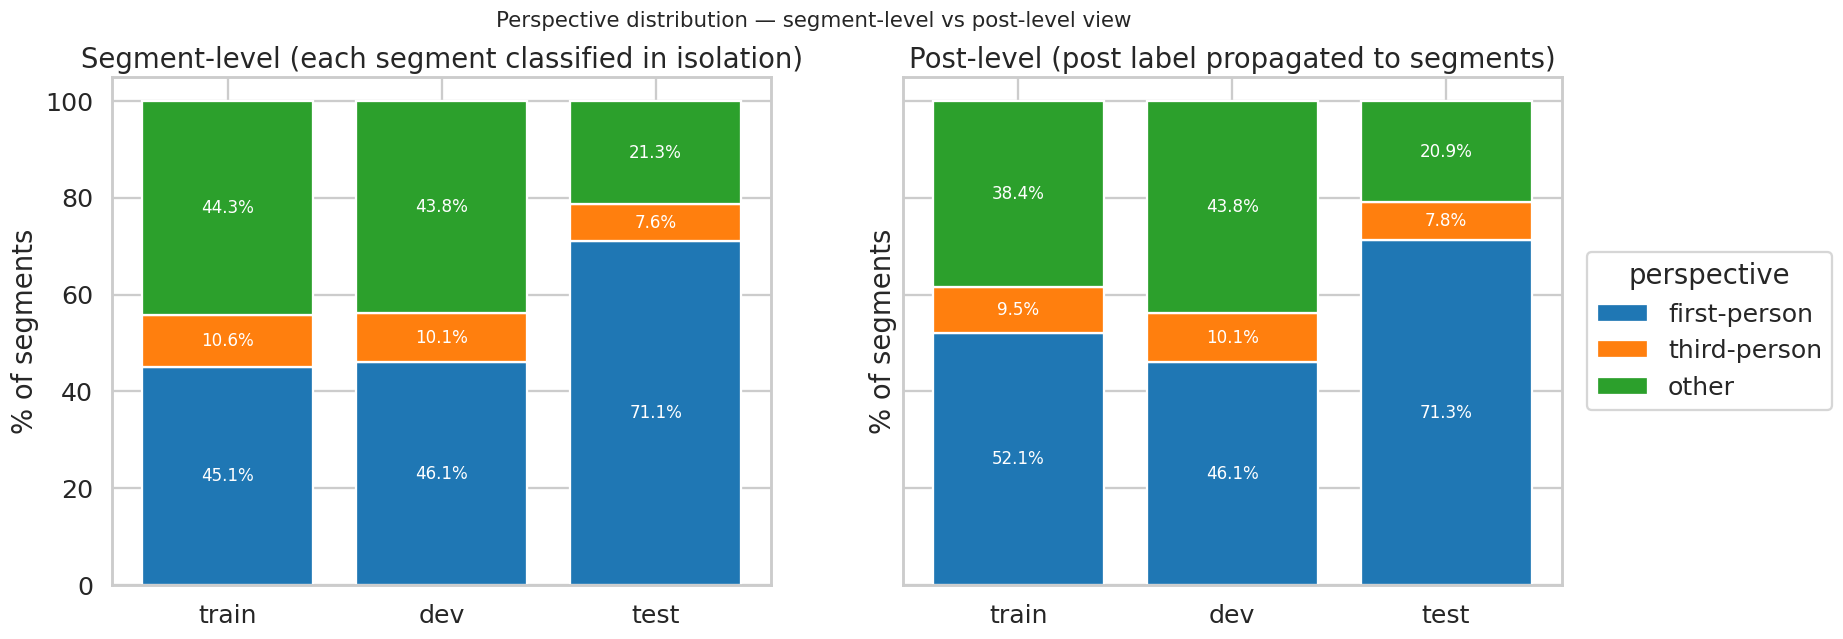

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)

def plot_stacked(ax, counts_pct, title):
    bottom = np.zeros(len(counts_pct.columns))
    for i, p in enumerate(persp_order):
        vals = counts_pct.loc[p].values
        ax.bar(counts_pct.columns, vals, bottom=bottom, label=p, color=MULTI_PALETTE[i])
        for j, v in enumerate(vals):
            if v > 2:
                ax.text(j, bottom[j] + v / 2, f"{v:.1f}%",
                        ha="center", va="center", fontsize=11, color="white")
        bottom += vals
    ax.set_title(title)
    ax.set_ylabel("% of segments")

plot_stacked(axes[0], persp_counts_pct,        "Segment-level (each segment classified in isolation)")
plot_stacked(axes[1], seg_counts_from_post_pct, "Post-level (post label propagated to segments)")

axes[1].legend(title="perspective", loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("Perspective distribution — segment-level vs post-level view", fontsize=14)
save_fig(fig, "10_perspective_segment_vs_post")
plt.show()

  saved -> out/plots/11_entity_rate_segment_vs_post.pdf


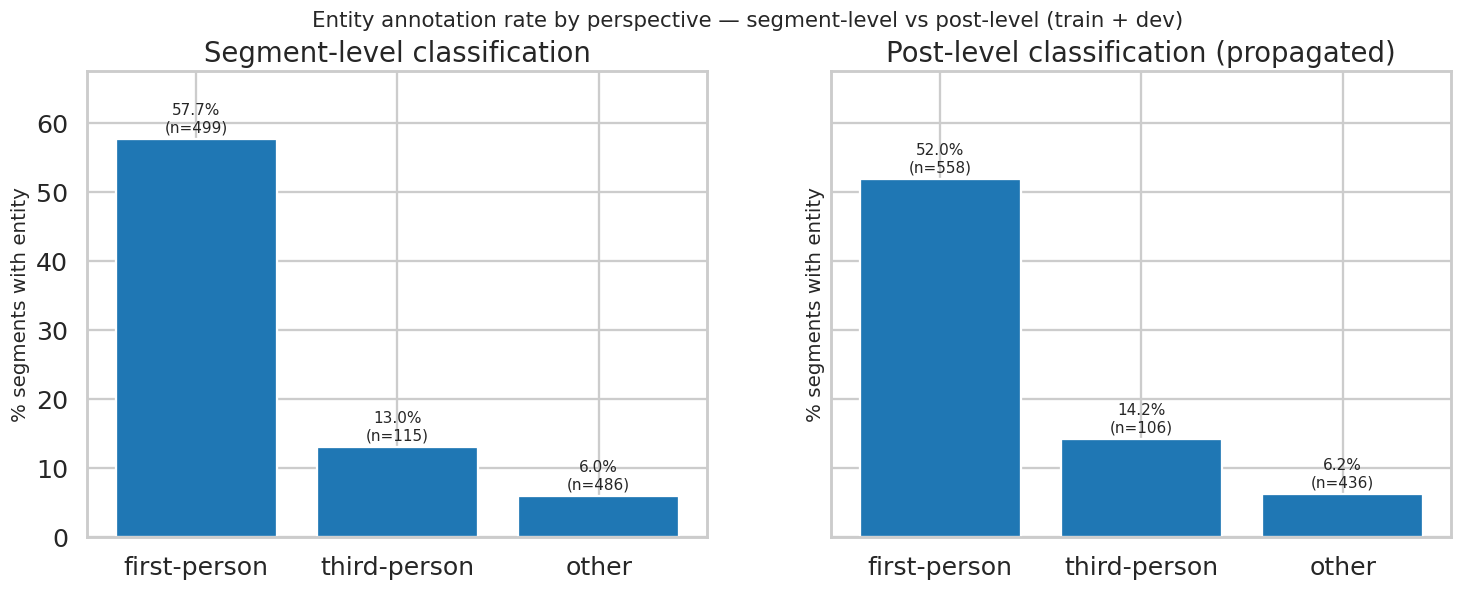

,count,entity_rate %
perspective_post,,
first-person,558,52.0
third-person,106,14.2
other,436,6.2


In [27]:
comb_post = pd.concat(
    [df_train.assign(split="train"), df_dev.assign(split="dev")],
    ignore_index=True,
)
comb_post["has_entity"] = comb_post["ner_tags"].map(lambda tags: any(t != "O" for t in tags))
ent_rate_post = comb_post.groupby("perspective_post")["has_entity"].agg(["mean", "count"]).reindex(persp_order)
ent_rate_post["entity_rate %"] = (100 * ent_rate_post["mean"]).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, ent_local, title in zip(
    axes,
    [ent_rate, ent_rate_post],
    ["Segment-level classification", "Post-level classification (propagated)"],
):
    bars = ax.bar(ent_local.index, ent_local["entity_rate %"], color=BLUE_PRIMARY)
    ax.set_title(title)
    ax.set_ylabel("% segments with entity", fontsize=13)
    ymax = max(float(ent_local["entity_rate %"].max()) * 1.3, 20)
    ax.set_ylim(0, ymax)
    for bar, n in zip(bars, ent_local["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{bar.get_height():.1f}%\n(n={n})", ha="center", fontsize=10)

fig.suptitle("Entity annotation rate by perspective — segment-level vs post-level (train + dev)", fontsize=14)
save_fig(fig, "11_entity_rate_segment_vs_post")
plt.show()
ent_rate_post[["count", "entity_rate %"]]

### Sample non-first-person full posts

In [ ]:
import random

post_perspective_map = {
    rec["ID"]: perspective_label.get(post_cache[post_cache_key(rec)], "other")
    for rec in post_corpus
}

def show_post_samples(split_name, perspective_value, n=3, max_chars=600):
    ids = [rec["ID"] for rec in post_corpus
           if rec["split"] == split_name and post_perspective_map[rec["ID"]] == perspective_value]
    if not ids:
        print(f"  (no {perspective_value} posts)")
        return
    rng = random.Random(42)
    sampled = rng.sample(ids, min(n, len(ids)))
    for i, pid in enumerate(sampled, 1):
        text = post_text_map[pid]
        if len(text) > max_chars:
            text = text[:max_chars] + " ..."
        print(f"  [{i}] ID={pid}  (n_segments={int((df_train['ID']==pid).sum() + (df_dev['ID']==pid).sum() + (df_test['ID']==pid).sum())})")
        print(f"      {text}")
        print()

for split_name in ["train", "dev", "test"]:
    print(f"=== {split_name} · third-person POSTS ===")
    show_post_samples(split_name, "third-person", n=3)

for split_name in ["train", "dev", "test"]:
    print(f"=== {split_name} · other POSTS ===")
    show_post_samples(split_name, "other", n=3)